# Lab 7: Predictive Modeling and Explainability

***
- **FIRST name**: Moffat
- **LAST name**: Muriithi
- **Student ID**:

Leave blank if individual:
- **Collaborator names**:
- **Collaborator student IDs**:
***

In today's lab, you will learn:

1. About Random Forests
2.   Using the LIME package for explanations for classification models.
3.   Using the SHAP package for explanations for classification models.

For this lab, you'll need the dataset `iris.csv` and `diabetes.csv`.


### Instructions

- **Collaboration**: You must submit your own work. The collaboration policy for the labs is Consultation Collaboration. You may verbally discuss concepts with your classmates, without exchanging written text, code, or detailed advice. You must develop your own solution and submit your own work. All sources of information used including books, websites, students you talked to, must be cited in the submission. Please see the course FAQ document for details on this collaboration policy. We will adhere to current Faculty of Science guidelines on dealing with suspected cases of plagiarism.
- **Software**: We highly recommend that students use Syzygy for completing labs and assignments. This is the software used by the TAs in the course, and we can guarantee that there will be no issues with incompatible environments or imports.
- **Filling out the Notebook**: You must use this notebook to complete your lab. You will execute the questions in the notebook. The questions might ask for a short answer in text form or for you to write and execute a piece of code. Make sure you enter your answer in either case only in the cell provided.
- **Important**:  Do not use a different cell, do not delete cells, and do not create a new cell. Creating new cells for your code is not compatible with the auto-grading system we are using and thus your assignment will not get grading properly and you will lose marks for that question. As a reminder you must remove the raise NotImplementedError() statements from each question when answering.
- **Rules for Datasets**: Any datasets used in the lab cannot be imported from cloud storage, e.g google drive, and must be read from a file either on your local computer or uploaded to the google colab notebook. Importing from cloud storage will result in a zero.
- **Submission Formatting**: When you are done, you will submit your work from the notebook. Make sure to save your notebook before running it, and then submit on Canvas the notebook file with your work completed. Name your file with an L followed by the lab number (ex: L7.ipynb). Failure to do so will result in a zero! Finally your name must be written at the top of the lab or assignment document.

In [1]:
#run this cell
!pip install lime
import sklearn
import sklearn.ensemble
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from __future__ import print_function
np.random.seed(1)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import lime
import lime.lime_tabular

np.random.seed(1)

# 1. Pre-processing the Data

In the following sections, we'll explore how LIME can be used to explain individual predictions by approximating the model locally. We will continue using the `iris` dataset, which we will load using [sklearn.datasets](https://scikit-learn.org/stable/api/sklearn.datasets.html).

This dataset contains three iris species: setosa, versicolor, and virginica. It also contains the flower's petal length, petal width, sepal length, and sepal width. Our goal in this lab is to use sklearn's Random Forest Classifier to predict what species of iris we have given its measurements.
To learn more about Random Forests, see [here](https://www.ibm.com/topics/random-forest).

In [2]:
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
pd.set_option('display.max_rows', None)  # No limit on the number of rows
pd.set_option('display.max_columns', None)  # No limit on the number of columns
pd.set_option('display.width', None)  # Disable line wrapping for wide dataframes
pd.set_option('display.max_colwidth', None)  # No limit on the width of each column
print(iris_df)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
5                  5.4               3.9                1.7               0.4   
6                  4.6               3.4                1.4               0.3   
7                  5.0               3.4                1.5               0.2   
8                  4.4               2.9                1.4               0.2   
9                  4.9               3.1                1.5               0.1   
10                 5.4               3.7                1.5               0.2   
11                 4.8      

# 2. Training and Explainability with LIME



**Question 2.1.** Recall that we denote `X` as our features and `Y` as our target. Separate the dataset into its features and target.

In [3]:
# YOUR CODE HERE
X = iris_df.drop('target', axis=1)
Y = iris_df['target']

In [4]:
#TEST CELL: do not delete!

We first split our X and Y datasets in two:
1. Training set: this subset is used to train the model. It usually makes up 80% of the data;
2. Testing set: this subset is used to test the model to see how it performs. It usually makes up 20% of the data.

This is done for the features and the targets separately. It's important that the test data is not used to train the model because it could lead to memorizing the data.

**Question 2.2.** Split the `iris` dataset into training and testing sets using [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html). The data is to be split into `X_train`, `X_test`, `Y_train`, `Y_test` respectively. The parameter `test_size` sets the proportion of data for the testing subset (set to 0.2). The `random_state` parameter controls how the data is shuffled before being split.

In [5]:
# YOUR CODE HERE
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

Let's first scale the features.

In [6]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Fit Random Forest model

A Random Forest is a type of ensemble model that builds multiple decision trees and averages their predictions. It performs well in most classifications problems and doesn't require much parameter tuning.

**Question 2.3.** We use the sklearn function `RandomForestClassifier` to fit our random forest classifier. The parameter `n_estimators` is the number of trees and is set to 500 (visit [this link](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) if you are having any trouble). Assign your answer to `rf_model`.

In [7]:
# YOUR CODE HERE
rf_model = RandomForestClassifier(n_estimators=500, random_state=1)
rf_model.fit(X_train_scaled, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Now that we have our model, we can start making predictions on our iris data.

**Question 2.4** Use the `.predict` method to make predictions and assign your answer to `Y_pred`. Make sure you use the right feature subset (training vs. testing)!



In [8]:
# YOUR CODE HERE
Y_pred = rf_model.predict(X_test_scaled)
print(X_test_scaled)
print("\nY_pred: ", Y_pred)

[[-0.04622511  2.34319467 -1.47902854 -1.31769898]
 [-0.89033581 -1.24028061 -0.45900886 -0.15407273]
 [ 0.91847283 -0.04578885  0.33433978  0.23380268]
 [-0.52857408  2.10429632 -1.42236078 -1.05911537]
 [ 2.48610699  1.86539796  1.46769499  1.00955351]
 [ 0.5567111   0.6709062   0.50434307  0.49238629]
 [ 1.28023456  0.1931095   0.73101411  1.39742892]
 [-0.89033581  1.86539796 -1.08235422 -1.05911537]
 [-1.37268478  0.43200785 -1.2523575  -1.31769898]
 [ 1.28023456  0.43200785  1.07102067  1.39742892]
 [-0.2873996  -0.76248391  0.22100426  0.10451088]
 [-0.52857408  2.10429632 -1.19568974 -1.05911537]
 [ 1.52140905 -0.04578885  1.18435619  1.13884531]
 [ 0.67729835  0.43200785  0.39100755  0.36309449]
 [ 0.19494938 -0.2846872   0.39100755  0.36309449]
 [-1.73444651  0.43200785 -1.42236078 -1.31769898]
 [-0.04622511 -1.00138226  0.10766874 -0.02478093]
 [-0.2873996  -0.04578885  0.39100755  0.36309449]
 [-0.52857408  0.90980456 -1.30902526 -1.05911537]
 [-1.01092305  0.43200785 -1.47

We print the X_test subset and Y_pred to better understand what's going on. X_test contains 30 random flowers and their metrics. Y_pred is an array of 30 predictions where 0 denotes **setosa**, 1 denotes **versicolor**, and 2 denotes **verginica**.

## Explanations

We first need to create the explainer from the lime module.

In [9]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_scaled,
    feature_names=X.columns,
    class_names=iris.target_names,
    mode='classification'
)

Now we choose an instance to explain, say the first one in the test set

In [10]:
instance = X_test_scaled[2]
print(instance)

[ 0.91847283 -0.04578885  0.33433978  0.23380268]


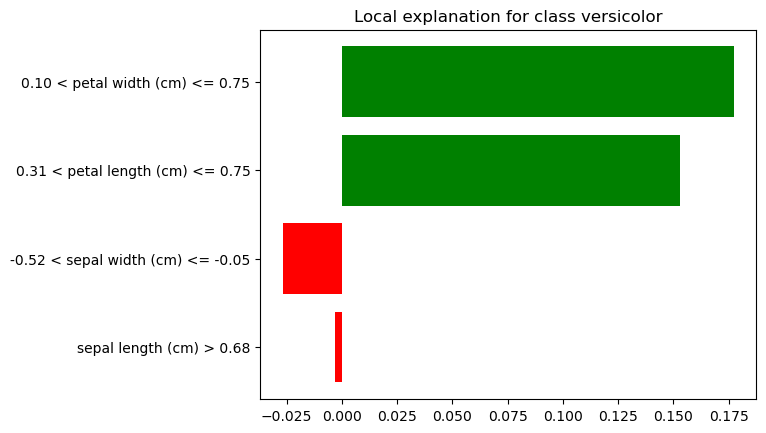

[('0.10 < petal width (cm) <= 0.75', 0.17722948108661954), ('0.31 < petal length (cm) <= 0.75', 0.15300365926626763), ('-0.52 < sepal width (cm) <= -0.05', -0.026792483734937353), ('sepal length (cm) > 0.68', -0.003027295790833983)]


In [11]:
exp = explainer.explain_instance(instance, rf_model.predict_proba, num_features=4)

# Visualize explanation
exp.as_pyplot_figure()
plt.show()

# Print feature importance
print(exp.as_list())

**Question 2.5** Write an explanation for what you see in the visualization.

The visualization explains the model's prediction for this specific instance regarding the versicolor class. The green bars show features that positively influenced the prediction towards versicolor, with a petal width between about 0.10 and 0.75 being the most dominant factor, closely followed by a petal length between 0.31 and 0.75. A sepal width between -0.52 and -0.05 provided slight evidence against this classification, while the sepal length greater than 0.68, had a small negative impact. In general the strong positive influence of the petal dimensions heavily outweighed the negative influence of the sepal dimensions.

**Question 2.6** Now get an explanation for another instance and write an explanation of what you see in the visualization.

The visualization explains the model's prediction for the versicolor class. The petal dimensions remain the positive influences, with a petal width between 0.10 and 0.75 and a petal length between 0.31 and 0.75 heavily driving the prediction towards versicolor. A sepal width between -0.05 and 0.67 also acts as a positive contributor, unlike in Question 2.5. The only feature providing evidence against the versicolor classification is a sepal length between -0.05 and 0.68, though its negative impact is almost completely small. Overall, the model is highly confident in this prediction due to three out of four features aligning with the versicolor class.

# 3. Explainability with SHAP

In this section, we will use SHAP to understand how different features contribute to model predictions. Unlike LIME, which focuses on local approximations, SHAP provides both local and global interpretability. We will be working with the `diabetes`dataset, which was gotten from [this link](https://www.kaggle.com/datasets/mathchi/diabetes-data-set).

In [12]:
#run this cell
!pip install shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import shap
shap.initjs
np.random.seed(1)

Let's load the `diabetes` dataset and extract our feature and target values.

In [13]:
diabetes_df = pd.read_csv("diabetes.csv")
print(diabetes_df.head(5))
print(diabetes_df.shape)

X = diabetes_df.drop('Outcome', axis=1)
Y = diabetes_df['Outcome']

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)


This dataset contains 8 baseline features collection from 768 female patients of Pima Indian descent, including age, number of pregnancies, body mass index, blood pressure, and other important measurements. Our goal in this section is to use sklearn's RandomForestClassifier to predict based on this diagnostic measurements whether a patient has diabetes. You can read more on the dataset [here](https://www.kaggle.com/datasets/mathchi/diabetes-data-set/data).

**Question 3.1** Split the `diabetes` dataset into training and testing sets using [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html). The data is to be split into `X_train`, `X_test`, `Y_train`, `Y_test` respectively. The parameter `test_size` sets the proportion of data for the testing subset (set to 0.2). The `random_state` parameter controls how the data is shuffled before being split.

In [14]:
# YOUR CODE HERE
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

Let's scale our features

In [15]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Fit and Predict using RandomForestClassifier model

**Question 3.2** We use the sklearn function `RandomForestClassifier` to fit our random forest classifier. The parameter `n_estimators` is the number of trees and is set to 500 (visit [this link](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) if you are having any trouble). Assign your answer to `rf_model`.

In [16]:
# YOUR CODE HERE
rf_model = RandomForestClassifier(n_estimators=500, random_state=1)
rf_model.fit(X_train_scaled, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

**Question 3.3** Use the `.predict` method to make predictions and assign your answer to `Y_pred`.


In [17]:
# YOUR CODE HERE
Y_pred = rf_model.predict(X_test_scaled)
print(X_test_scaled)
print("\nY_pred: ", Y_pred)

[[ 0.92573636  0.46602687  0.26053603 ... -0.76497935  0.56009786
   1.50008581]
 [-0.84682744  0.9401881  -0.44931111 ... -0.75186334 -0.87067912
  -0.95741055]
 [ 0.63030906 -0.38746335 -0.44931111 ... -0.89613942 -0.78813429
  -0.53370428]
 ...
 [ 1.22116366  2.1097858   0.46334951 ...  2.10742614 -0.99908218
   0.82215578]
 [ 0.33488176  0.46602687  0.66616298 ... -4.17514112  0.53869735
   3.02542839]
 [ 0.03945446 -0.98806757 -3.49151318 ... -0.50265921  0.44698088
  -0.19473927]]

Y_pred:  [1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 0 1 0 1 0
 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 0 1 0 0 1 1 1 1 1 1 0
 1 0 1 0 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1 1 0 0 1
 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1 0 0 1 1 0 0 0
 0 0 0 1 0 0]


## Explanations

We first need to create the explainer from the SHAP module and generate the SHAP values

In [18]:
# We need to add the feature names so the plots are visualized better
X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test_scaled)
np.shape(shap_values.values)

(154, 8, 2)

Now we choose an instance to explain, say the tenth one in the test set and use the waterfall plot to visualize this

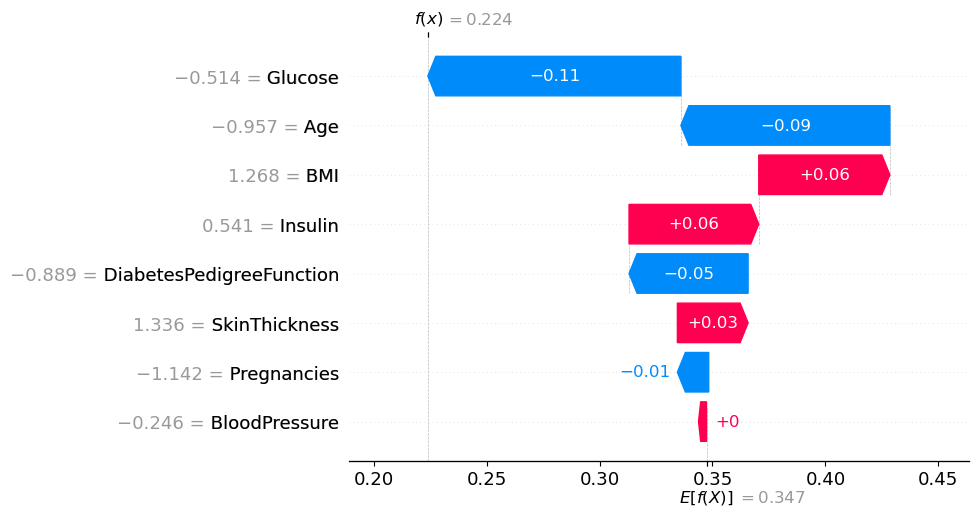

In [19]:
instance_idx = 9
# Note: For classification, shap_values typically has the shape (n_samples, n_features, n_classes).
# Here, we use [:, 1] to visualize the feature contributions specifically for Class 1 (Positive for Diabetes).
shap.plots.waterfall(shap_values[instance_idx, :, 1])

**Question 3.4** What features most influenced the model's prediction for this individual and why?

The features that most influenced the model's prediction were Glucose and Age. The model starts with a baseline expected value of 0.347. However, this patient's below-average scaled Glucose (-0.514) pushed the prediction down by 0.11, and their lower scaled Age (-0.957) further reduced it by 0.09. While higher-than-average BMI and Insulin values provided some counteracting positive influence (pushing the probability up by 0.06 each), the strong negative pulls from Glucose and Age were the primary reasons the final prediction dropped to 0.224, driving the model toward a negative diabetes classification.

We are going to explore another plot called the beeswarm, you can read up on it [here](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/beeswarm.html)

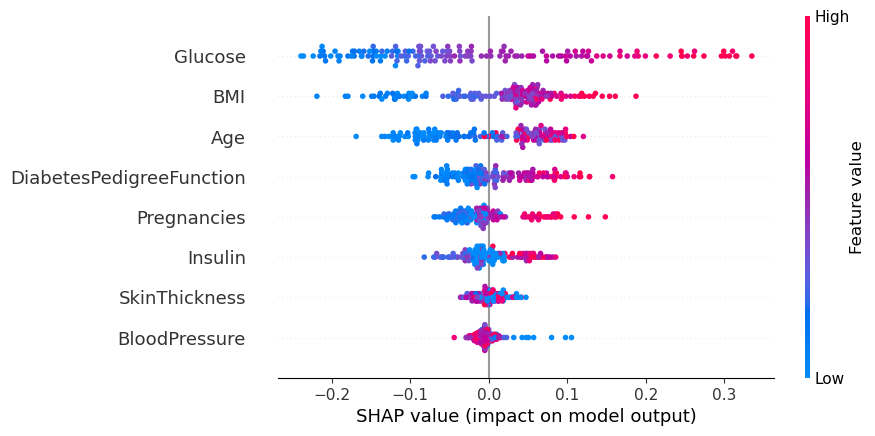

In [20]:
instance_idx = 0
shap.plots.beeswarm(shap_values[:, :, 1])

**Question 3.5** What features generally have the greatest impact on predicting diabetes across the dataset and how did you come to this conclusion?

The features that generally have the greatest impact on predicting diabetes are Glucose, BMI, and Age. The visual spread of the dots confirms this, as these top features have the widest horizontal distribution along the x-axis, indicating strong pushes on the model's output. Furthermore, the color coding reveals a clear pattern for these top predictors: high values, represented by red dots, consistently fall on the positive side of the SHAP value axis, demonstrating that higher Glucose, BMI and Age strongly drive the model toward predicting positive for diabetes.

# Rubric

| Question | Points|
|----------|----------|
| 2.1.    | 10   |
| 2.2.    | 10   |
| 2.3.    | 10   |
| 2.4.    | 5   |
| 2.5.    | 15   |
| 2.6.    | 15   |
| 3.1.    | 10   |
| 3.2.    | 10   |
| 3.3.    | 5   |
| 3.4.    | 10   |
| 3.5.    | 10   |
| Total:    | 110   |